<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h1>LogisticRegression</h1>
    <h3>SMOTE -> LogisticRegression + GridSearchCV</h3>
<hr>
</div>

In [65]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score

In [66]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display, print_evaluation
from scripts.decision_tree import determine_parameter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [68]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [69]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [72]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']),    
    ], remainder=Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', MinMaxScaler())
        ])  
)

In [73]:
X_train = transformer.fit_transform(X_train)

In [74]:
X_test = transformer.transform(X_test)

In [75]:
X_test.shape

(51070, 51)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. SMOTE+Tomek</h2>
</div>

In [76]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [77]:
# Initialize the SMOTE
rus = SMOTETomek(random_state=42)

# Fit and apply the undersampling
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

In [78]:
# The resampled data is now balanced
print("Shape of X before undersampling:", X_train.shape)
print("Shape of X after undersampling:", X_resampled.shape)
print("Value counts before undersampling:", pd.Series(y_train).value_counts())
print("Value counts after undersampling:", pd.Series(y_resampled).value_counts())

Shape of X before undersampling: (204277, 51)
Shape of X after undersampling: (360328, 51)
Value counts before undersampling: Default
0    180524
1     23753
Name: count, dtype: int64
Value counts after undersampling: Default
0    180164
1    180164
Name: count, dtype: int64


In [79]:
X_train, y_train = X_resampled, y_resampled

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>3. LogisticRegression</h2>
</div>

In [80]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as IPipeline
from sklearn.feature_selection import SelectFromModel

In [81]:
pipeline = IPipeline([
    ('feature_selection', SelectFromModel(estimator=LogisticRegression(random_state=43, max_iter = 1000, C= 0.01, penalty= 'l1',solver= 'liblinear'))),
    ('classifier', LogisticRegression(random_state = 43, max_iter = 1000, class_weight='balanced'))
])

In [82]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(C=0.01,
                                                              max_iter=1000,
                                                              penalty='l1',
                                                              random_state=43,
                                                              solver='liblinear'))),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=43))])

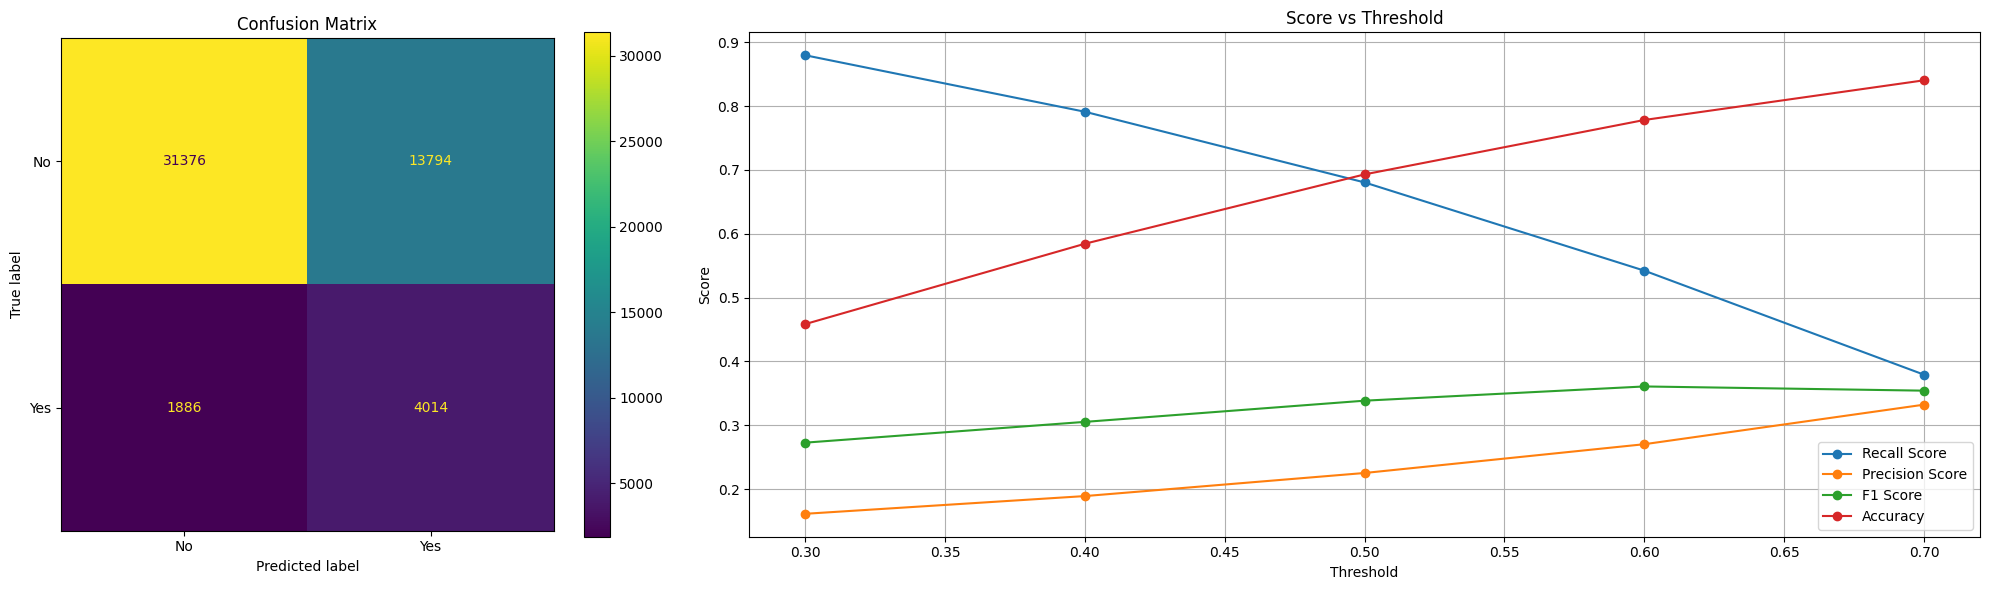

,Score,Percentage
0,Training Accuracy,70.44%
1,Test Accuracy,69.30%
2,Recall Score,37.93%
3,Precision Score,33.24%
4,Accuracy Score,84.03%
5,F1 Score,35.43%
6,ROC AUC Score,68.75%


In [83]:
scores_df, threshold_df = print_evaluation(pipeline, X_train, y_train, X_test, y_test)
scores_df

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>4. GridSearchCV</h2>
</div>

In [84]:
params = [
    {     
        "classifier__C": [0.001, 0.01, 0.1, 10, 100],
        "classifier__penalty": ['l1', 'l2'],
        'classifier__solver': ['liblinear'],
    },
    {
        "classifier__C": [ 0.01, 0.1, 10, 100],
        "classifier__penalty": ['l1', 'l2'],
        'classifier__solver': ['lbfgs','newton-cg', 'newton-cholesky']
    },
    {
        "classifier__C": [0.01, 0.1, 10, 100],
        "classifier__penalty": ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        "classifier__C": [0.01, 0.1, 10, 100],
        "classifier__penalty": ['l1', 'l2'],
        'classifier__solver': ['lbfgs','newton-cg', 'newton-cholesky']
    }
]

In [85]:
cv = GridSearchCV(pipeline, params, cv=5, n_jobs=-1, verbose=True, scoring=make_scorer(fbeta_score, beta=2, pos_label=1));

In [86]:
cv.fit(X_train, y_train)

Fitting 5 folds for each of 66 candidates, totalling 330 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectFromModel(estimator=LogisticRegression(C=0.01,
                                                                                     max_iter=1000,
                                                                                     penalty='l1',
                                                                                     random_state=43,
                                                                                     solver='liblinear'))),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=43))]),
             n_jobs=-1,
             param_grid=[{'classifier__C': [0.001, 0.01, 0.1, 10, 100],
                          'classifier__p...
                          'classifier__solver': ['lbfgs', 'newton-cg',
                                                 'newton-cholesky']},
                         {'classifier__C': [0.01, 0.1, 10, 100],
                          'classifier__penalty': ['l1', 'l2'],
                          'classifier__solver': ['liblinear']},
                         {'classifier__C': [0.01, 0.1, 10, 100],
                          'classifier__penalty': ['l1', 'l2'],
                          'classifier__solver': ['lbfgs', 'newton-cg',
                                                 'newton-cholesky']}],
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2, pos_label=1),
             verbose=True)

In [87]:
print("Best Parameters:", cv.best_params_)
print("Best CV Score:", cv.best_score_)

Best Parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV Score: 0.7129836279621327


In [88]:
model = cv.best_estimator_
model

Pipeline(steps=[('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(C=0.01,
                                                              max_iter=1000,
                                                              penalty='l1',
                                                              random_state=43,
                                                              solver='liblinear'))),
                ('classifier',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, random_state=43))])

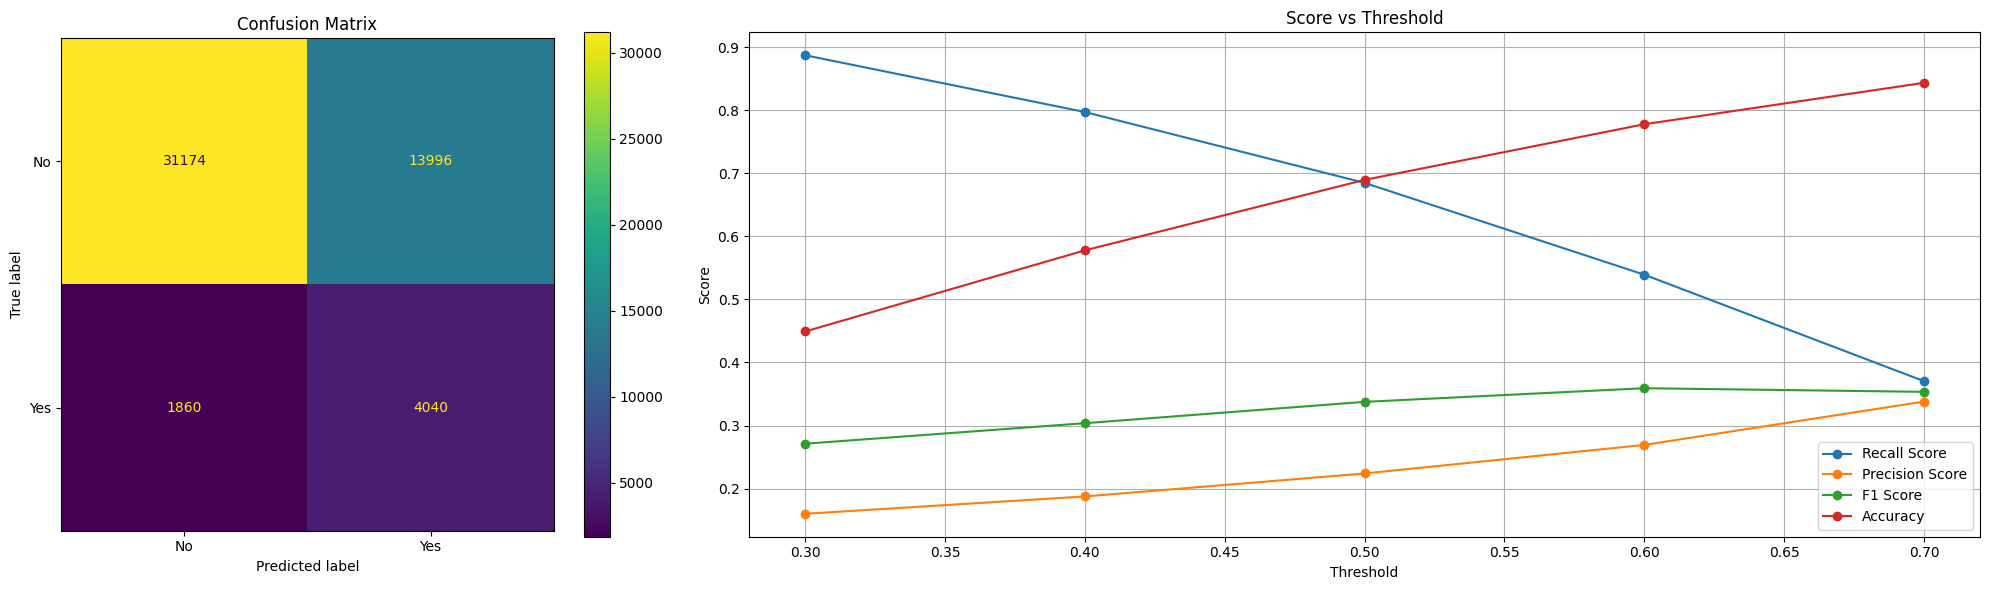

,Score,Percentage
0,Training Accuracy,70.31%
1,Test Accuracy,68.95%
2,Recall Score,37.03%
3,Precision Score,33.80%
4,Accuracy Score,84.35%
5,F1 Score,35.34%
6,ROC AUC Score,68.74%


In [89]:
scores_df, threshold_df = print_evaluation(model, X_train, y_train, X_test, y_test)
scores_df

In [90]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.887,0.160,0.271,0.449
0.400,0.797,0.188,0.304,0.578
0.500,0.685,0.224,0.338,0.690
0.600,0.539,0.269,0.359,0.778
0.700,0.370,0.338,0.353,0.843
